# 零基础实战机器学习

## 第15讲 会员流失情况判断

作者 黄佳

极客时间专栏链接：https://time.geekbang.org/column/intro/438


问题：判断易速鲜花会员的是否会流失情况

易速鲜花公司拥有多年的会员记录，以及会员停止续费的情况。

通过逻辑回归和神经网络等机器学习模型，我们可以判断出客户是否离开，这是一个典型的的二元分类问题。


## 数据的读入和预处理

In [8]:
import numpy as np # 导入NumPy
import pandas as pd # 导入Pandas
import matplotlib.pyplot as plt # 导入matplotlib.pyplot
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统常用字体
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac系统常用字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [9]:
df_member = pd.read_csv('易速鲜花会员留存.csv') # 导入数据包
df_member #显示数据

,用户码,性别,玫瑰套餐,紫罗兰套餐,郁金香套餐,百合套餐,康乃馨套餐,胡姬花套餐,生日套餐,情人节套餐,会员卡类型,入会月数,会费支付方式,平均月消费,总消费,已停付会费
0,1,女,是,是,否,是,否,是,是,否,年卡,9,手工转账,65.60,593.3,否
1,2,男,否,否,否,否,否,否,否,是,月卡,9,手工转账,59.90,542.4,否
2,3,男,否,否,否,否,是,否,否,否,月卡,4,就餐时付费,73.90,280.85,是
3,4,男,是,否,否,是,是,否,是,是,月卡,13,就餐时付费,98.00,1237.85,是
4,5,女,否,是,否,否,否,是,是,是,月卡,9,花呗付款,69.40,571.45,否
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7039,女,否,否,是,否,否,是,否,否,年卡,13,手工转账,55.15,742.9,否
7039,7040,男,否,否,否,是,否,否,否,否,月卡,2,手工转账,50.30,92.75,否
7040,7041,男,是,否,否,否,否,否,否,是,月卡,22,就餐时付费,85.10,1873.7,是
7041,7042,男,是,是,是,否,是,是,否,是,双年卡,67,手工转账,67.85,4627.65,否


### 数据清洗

In [10]:
#把总消费字段转换成数值字段
df_member['总消费'] = pd.to_numeric(df_member['总消费'], errors='coerce')
df_member['总消费'].fillna(0, inplace=True)

### 数据可视化

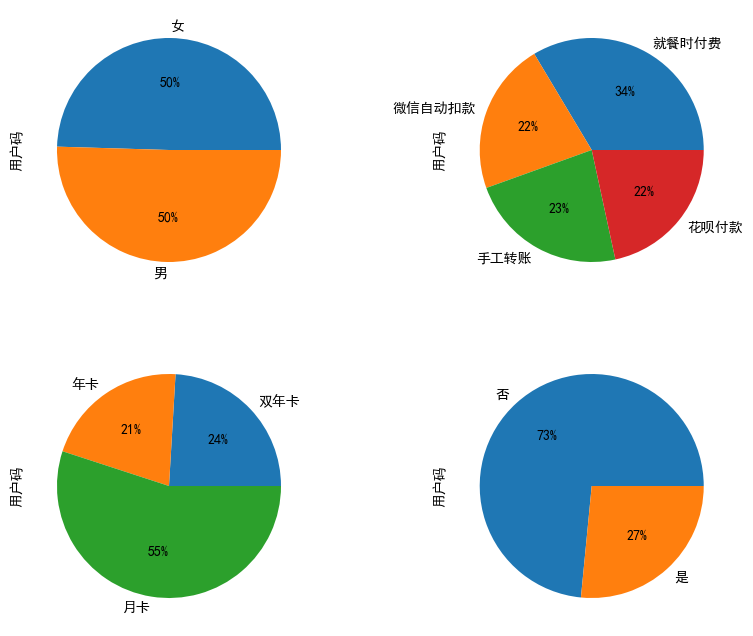

In [11]:
plt.figure(figsize=(10,8))
plt.subplot(2, 2, 1)
ax = df_member.groupby('性别').count()['用户码'].plot.pie(autopct='%1.0f%%') #饼图
plt.subplot(2, 2, 2)
ax = df_member.groupby('会费支付方式').count()['用户码'].plot.pie(autopct='%1.0f%%') #饼图
plt.subplot(2, 2, 3)
ax = df_member.groupby('会员卡类型').count()['用户码'].plot.pie(autopct='%1.0f%%') #饼图
plt.subplot(2, 2, 4)
ax = df_member.groupby('已停付会费').count()['用户码'].plot.pie(autopct='%1.0f%%') #饼图
plt.show() #显示

### 特征工程

In [12]:
df_member['已停付会费'].replace(to_replace='是', value=1, inplace=True) #流失-1
df_member['已停付会费'].replace(to_replace='否',  value=0, inplace=True) #未流失-0

In [13]:
df_member['性别'].replace(to_replace='女', value=0, inplace=True) #女生-0
df_member['性别'].replace(to_replace='男', value=1, inplace=True) #男生-1

In [14]:
# 字段中'Yes' or 'No'转换成为模型可以读取的数值,（布尔型数据，也是数值数据）
binary_features = ['玫瑰套餐', '紫罗兰套餐', '郁金香套餐', '百合套餐', '康乃馨套餐', '胡姬花套餐', 
                   '生日套餐','情人节套餐']
for field in binary_features:
    df_member[field] = df_member[field] == '是'

In [15]:
df_member

,用户码,性别,玫瑰套餐,紫罗兰套餐,郁金香套餐,百合套餐,康乃馨套餐,胡姬花套餐,生日套餐,情人节套餐,会员卡类型,入会月数,会费支付方式,平均月消费,总消费,已停付会费
0,1,0,True,True,False,True,False,True,True,False,年卡,9,手工转账,65.60,593.30,0
1,2,1,False,False,False,False,False,False,False,True,月卡,9,手工转账,59.90,542.40,0
2,3,1,False,False,False,False,True,False,False,False,月卡,4,就餐时付费,73.90,280.85,1
3,4,1,True,False,False,True,True,False,True,True,月卡,13,就餐时付费,98.00,1237.85,1
4,5,0,False,True,False,False,False,True,True,True,月卡,9,花呗付款,69.40,571.45,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7039,0,False,False,True,False,False,True,False,False,年卡,13,手工转账,55.15,742.90,0
7039,7040,1,False,False,False,True,False,False,False,False,月卡,2,手工转账,50.30,92.75,0
7040,7041,1,True,False,False,False,False,False,False,True,月卡,22,就餐时付费,85.10,1873.70,1
7041,7042,1,True,True,True,False,True,True,False,True,双年卡,67,手工转账,67.85,4627.65,0


### 数据整理
先做数据整理工作，把每个数据字段都转换为可以处理的字段

In [16]:
# 分类字段哑变量
category_features = ['会员卡类型', '会费支付方式']
df_member = pd.get_dummies(df_member, drop_first=True, columns=category_features)
df_member

,用户码,性别,玫瑰套餐,紫罗兰套餐,郁金香套餐,百合套餐,康乃馨套餐,胡姬花套餐,生日套餐,情人节套餐,入会月数,平均月消费,总消费,已停付会费,会员卡类型_年卡,会员卡类型_月卡,会费支付方式_微信自动扣款,会费支付方式_手工转账,会费支付方式_花呗付款
0,1,0,True,True,False,True,False,True,True,False,9,65.60,593.30,0,True,False,False,True,False
1,2,1,False,False,False,False,False,False,False,True,9,59.90,542.40,0,False,True,False,True,False
2,3,1,False,False,False,False,True,False,False,False,4,73.90,280.85,1,False,True,False,False,False
3,4,1,True,False,False,True,True,False,True,True,13,98.00,1237.85,1,False,True,False,False,False
4,5,0,False,True,False,False,False,True,True,True,9,69.40,571.45,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7039,0,False,False,True,False,False,True,False,False,13,55.15,742.90,0,True,False,False,True,False
7039,7040,1,False,False,False,True,False,False,False,False,2,50.30,92.75,0,False,True,False,True,False
7040,7041,1,True,False,False,False,False,False,False,True,22,85.10,1873.70,1,False,True,False,False,False
7041,7042,1,True,True,True,False,True,True,False,True,67,67.85,4627.65,0,False,False,False,True,False


### 构建特征集和标签集

In [17]:
X = df_member.drop(['用户码','已停付会费'], axis = 1) # 构建特征集，用户码字段属于无用特征
y = df_member.已停付会费.values # 构建标签集

### 拆分数据集

In [18]:
from sklearn.model_selection import train_test_split #导入train_test_split模块
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2) #拆分数据集

## 选择算法

这里我们比较逻辑回归和神经网络两种算法

### 逻辑回归模型

### 导入模型

In [19]:
from sklearn.linear_model import LogisticRegression #导入逻辑回归模型
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# 创建模型
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
# 创建模型
model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
lr = LogisticRegression(max_iter=1000) # lr,就代表是逻辑回归模型
svm = SVC(kernel='linear', probability=False, random_state=42, verbose=True, max_iter=1000) # 支持向量集
model_nb = GaussianNB()
model_rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
print(X_train.shape)

(5634, 17)


### 训练机器

In [20]:
import time

start_time = time.time()
lr.fit(X_train,y_train) # fit,就相当于是梯度下降
print("lr time elaps {}".format(time.time() - start_time))

start_time = time.time()
svm.fit(X_train, y_train)
print("svm time elaps {}".format(time.time() - start_time))

start_time = time.time()
model_nb.fit(X_train, y_train)
print("model_nb time elaps {}".format(time.time() - start_time))

start_time = time.time()
model_xgb.fit(X_train, y_train)
print("model_xgb time elaps {}".format(time.time() - start_time))

start_time = time.time()
model_rf.fit(X_train, y_train)
print("model_rf time elaps {}".format(time.time() - start_time))

start_time = time.time()
model_dt.fit(X_train, y_train)
print("model_dt time elaps {}".format(time.time() - start_time))


y_pred_nb = model_nb.predict(X_test)
y_pred_lr = lr.predict(X_test)
y_pred_svm = svm.predict(X_test)
y_pred_xgb = model_xgb.predict(X_test)
y_pred_rf = model_rf.predict(X_test)
y_pred_dt = model_dt.predict(X_test)


lr time elaps 0.499021053314209
[LibSVM]svm time elaps 0.05385589599609375
model_nb time elaps 0.0029921531677246094
model_xgb time elaps 0.6550757884979248
model_rf time elaps 0.2909977436065674
model_dt time elaps 0.009974002838134766


### 评估分数

In [21]:
print("SK-learn逻辑回归预测准确率{:.2f}%".format(lr.score(X_test,y_test)*100))
print("SK-learn svm预测准确率{:.2f}%".format(svm.score(X_test,y_test)*100))
print("SK-learn 朴素贝叶斯预测准确率{:.2f}%".format(model_nb.score(X_test,y_test)*100))
print("SK-learn xgboost预测准确率{:.2f}%".format(model_xgb.score(X_test,y_test)*100))
print("SK-learn 随机森林预测准确率{:.2f}%".format(model_rf.score(X_test,y_test)*100))
print("SK-learn 决策树预测准确率{:.2f}%".format(model_dt.score(X_test,y_test)*100))

print("===")
print("真值 {}".format(y_test[3]))
print("y_pred_nb {}".format(y_pred_nb[3]))
print("y_pred_lr {}".format(y_pred_lr[3]))
print("y_pred_svm {}".format(y_pred_svm[3]))
print("y_pred_xgb {}".format(y_pred_xgb[3]))
print("y_pred_rf {}".format(y_pred_rf[3]))
print("y_pred_dt {}".format(y_pred_dt[3]))


SK-learn逻辑回归预测准确率77.64%
SK-learn svm预测准确率60.26%
SK-learn 朴素贝叶斯预测准确率71.19%
SK-learn xgboost预测准确率76.22%
SK-learn 随机森林预测准确率76.93%
SK-learn 决策树预测准确率77.15%
===
真值 0
y_pred_nb 0
y_pred_lr 0
y_pred_svm 0
y_pred_xgb 0
y_pred_rf 0
y_pred_dt 0


                     Accuracy   ROC AUC
Naive Bayes          0.711852  0.797729
Logistic Regression  0.776437  0.837308
SVM                  0.602555  0.598926
XGBoost              0.762243  0.814057
Random Forest        0.769340  0.841144
Decision Tree        0.771469  0.830261


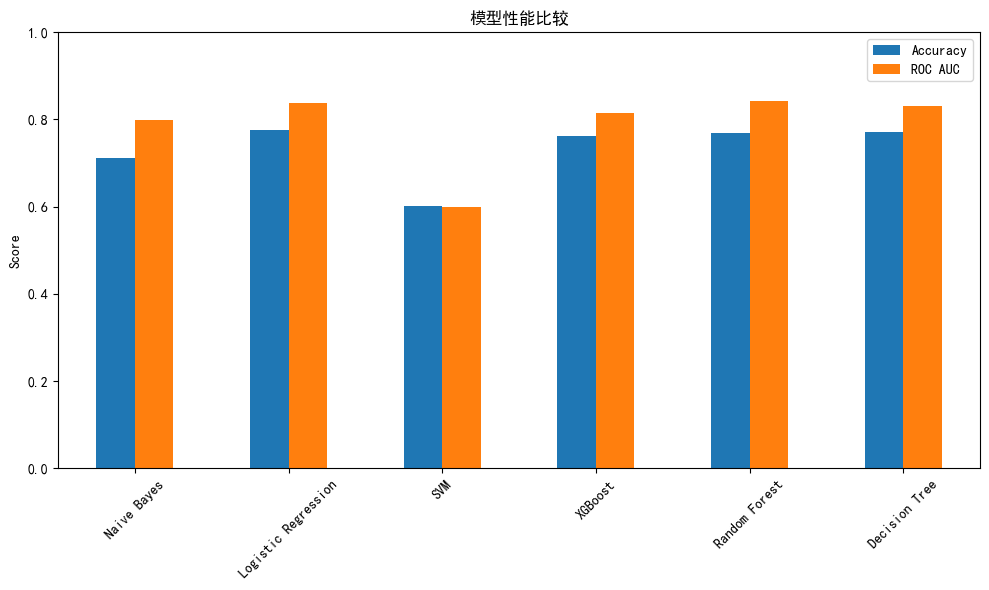

In [25]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

y_proba_nb = model_nb.predict_proba(X_test)[:, 1]
y_proba_lr = lr.predict_proba(X_test)[:, 1]
#y_proba_svm = svm.predict_proba(X_test)[:, 1]
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]
y_proba_dt = model_dt.predict_proba(X_test)[:, 1]

# 汇总所有模型的准确率和 ROC AUC
results = {
    "Naive Bayes": [accuracy_score(y_test, y_pred_nb), roc_auc_score(y_test, y_proba_nb)],
    "Logistic Regression": [accuracy_score(y_test, y_pred_lr), roc_auc_score(y_test, y_proba_lr)],
    "SVM": [accuracy_score(y_test, y_pred_svm), roc_auc_score(y_test, y_pred_svm)],
    "XGBoost": [accuracy_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_proba_xgb)],
    "Random Forest": [accuracy_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)],
    "Decision Tree": [accuracy_score(y_test, y_pred_dt), roc_auc_score(y_test, y_proba_dt)],
}

# 转换为 DataFrame
results_df = pd.DataFrame(results, index=["Accuracy", "ROC AUC"]).T
print(results_df)

# 可视化比较
results_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), title="模型性能比较")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 预测结果

In [26]:
y_pred=lr.predict(X_test)
print("逻辑回归对测试集第一个用户的预测结果", y_pred[0])

逻辑回归对测试集第一个用户的预测结果 0


### 归一化

In [27]:
from sklearn.preprocessing import MinMaxScaler #导入归一化缩放器
scaler = MinMaxScaler() #创建归一化缩放器
X_train_minmax = scaler.fit_transform(X_train) #拟合并转换训练集数据
X_test_minmax = scaler.transform(X_test) #转换测试集数据

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 使用归一化的数据集合

In [28]:
from sklearn.linear_model import LogisticRegression #导入逻辑回归模型
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
# 创建模型
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
# 创建模型
model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
lr = LogisticRegression(max_iter=1000) # lr,就代表是逻辑回归模型
svm = SVC(kernel='linear', probability=False, random_state=42, verbose=True, max_iter=1000) # 支持向量集
model_nb = GaussianNB()
model_rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)


lr.fit(X_train_minmax,y_train) # fit,就相当于是梯度下降
svm.fit(X_train_minmax, y_train)
model_nb.fit(X_train_minmax, y_train)
model_xgb.fit(X_train_minmax, y_train)
model_rf.fit(X_train_minmax, y_train)
model_dt.fit(X_train_minmax, y_train)


y_pred_nb = model_nb.predict(X_test_minmax)
y_pred_lr = lr.predict(X_test_minmax)
y_pred_svm = svm.predict(X_test_minmax)
y_pred_xgb = model_xgb.predict(X_test_minmax)
y_pred_rf = model_rf.predict(X_test_minmax)
y_pred_dt = model_dt.predict(X_test_minmax)

print("SK-learn逻辑回归预测准确率{:.2f}%".format(lr.score(X_test_minmax,y_test)*100))
print("SK-learn svm预测准确率{:.2f}%".format(svm.score(X_test_minmax,y_test)*100))
print("SK-learn 朴素贝叶斯预测准确率{:.2f}%".format(model_nb.score(X_test_minmax,y_test)*100))
print("SK-learn xgboost预测准确率{:.2f}%".format(model_xgb.score(X_test_minmax,y_test)*100))
print("SK-learn 随机森林预测准确率{:.2f}%".format(model_rf.score(X_test_minmax,y_test)*100))
print("SK-learn 决策树预测准确率{:.2f}%".format(model_dt.score(X_test_minmax,y_test)*100))

print("===")
print("真值 {}".format(y_test[3]))
print("y_pred_nb {}".format(y_pred_nb[3]))
print("y_pred_lr {}".format(y_pred_lr[3]))
print("y_pred_svm {}".format(y_pred_svm[3]))
print("y_pred_xgb {}".format(y_pred_xgb[3]))
print("y_pred_rf {}".format(y_pred_rf[3]))
print("y_pred_dt {}".format(y_pred_dt[3]))


[LibSVM]SK-learn逻辑回归预测准确率77.93%
SK-learn svm预测准确率66.57%
SK-learn 朴素贝叶斯预测准确率71.19%
SK-learn xgboost预测准确率76.22%
SK-learn 随机森林预测准确率76.93%
SK-learn 决策树预测准确率77.15%
===
真值 0
y_pred_nb 0
y_pred_lr 0
y_pred_svm 0
y_pred_xgb 0
y_pred_rf 0
y_pred_dt 0


                     Accuracy   ROC AUC
Naive Bayes          0.711852  0.797434
Logistic Regression  0.779276  0.837743
SVM                  0.665720  0.716090
XGBoost              0.762243  0.814057
Random Forest        0.769340  0.841146
Decision Tree        0.771469  0.830261


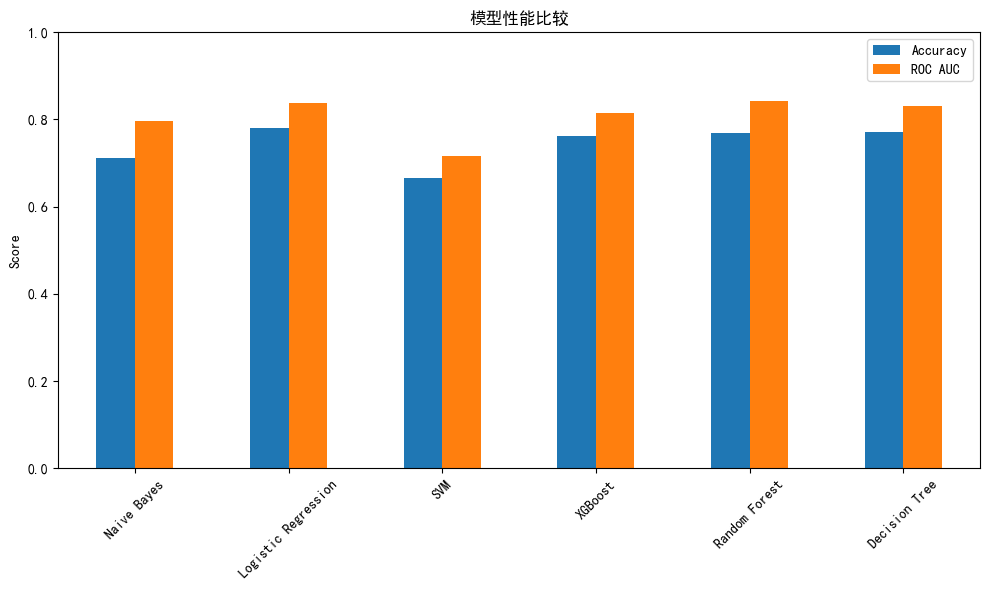

In [29]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

y_proba_nb = model_nb.predict_proba(X_test_minmax)[:, 1]
y_proba_lr = lr.predict_proba(X_test_minmax)[:, 1]
#y_proba_svm = svm.predict_proba(X_test)[:, 1]
y_proba_xgb = model_xgb.predict_proba(X_test_minmax)[:, 1]
y_proba_rf = model_rf.predict_proba(X_test_minmax)[:, 1]
y_proba_dt = model_dt.predict_proba(X_test_minmax)[:, 1]

# 汇总所有模型的准确率和 ROC AUC
results = {
    "Naive Bayes": [accuracy_score(y_test, y_pred_nb), roc_auc_score(y_test, y_proba_nb)],
    "Logistic Regression": [accuracy_score(y_test, y_pred_lr), roc_auc_score(y_test, y_proba_lr)],
    "SVM": [accuracy_score(y_test, y_pred_svm), roc_auc_score(y_test, y_pred_svm)],
    "XGBoost": [accuracy_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_proba_xgb)],
    "Random Forest": [accuracy_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)],
    "Decision Tree": [accuracy_score(y_test, y_pred_dt), roc_auc_score(y_test, y_proba_dt)],
}

# 转换为 DataFrame
results_df = pd.DataFrame(results, index=["Accuracy", "ROC AUC"]).T
print(results_df)

# 可视化比较
results_df.plot(kind='bar', figsize=(10, 6), ylim=(0, 1), title="模型性能比较")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 使用标准化的数据集合

In [30]:
from sklearn.linear_model import LogisticRegression #导入逻辑回归模型
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
# 创建模型
model_dt = DecisionTreeClassifier(max_depth=5, random_state=43)
# 创建模型
model_xgb = XGBClassifier(random_state=43, use_label_encoder=False, eval_metric='logloss')
lr = LogisticRegression(max_iter=1000) # lr,就代表是逻辑回归模型
svm = SVC(kernel='linear', probability=False, random_state=43, verbose=True, max_iter=1000) # 支持向量集
model_nb = GaussianNB()
model_rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=43
)

print(X_train_scaled.shape)

lr.fit(X_train_scaled,y_train) # fit,就相当于是梯度下降
svm.fit(X_train_scaled, y_train)
model_nb.fit(X_train_scaled, y_train)
model_xgb.fit(X_train_scaled, y_train)
model_rf.fit(X_train_scaled, y_train)
model_dt.fit(X_train_scaled, y_train)


y_pred_nb = model_nb.predict(X_test_scaled)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_svm = svm.predict(X_test_scaled)
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_pred_rf = model_rf.predict(X_test_scaled)
y_pred_dt = model_dt.predict(X_test_scaled)

print("SK-learn逻辑回归预测准确率{:.2f}%".format(lr.score(X_test_scaled,y_test)*100))
print("SK-learn svm预测准确率{:.2f}%".format(svm.score(X_test_scaled,y_test)*100))
print("SK-learn 朴素贝叶斯预测准确率{:.2f}%".format(model_nb.score(X_test_scaled,y_test)*100))
print("SK-learn xgboost预测准确率{:.2f}%".format(model_xgb.score(X_test_scaled,y_test)*100))
print("SK-learn 随机森林预测准确率{:.2f}%".format(model_rf.score(X_test_scaled,y_test)*100))
print("SK-learn 决策树预测准确率{:.2f}%".format(model_dt.score(X_test_scaled,y_test)*100))

print("===")
print("真值 {}".format(y_test[3]))
print("y_pred_nb {}".format(y_pred_nb[3]))
print("y_pred_lr {}".format(y_pred_lr[3]))
print("y_pred_svm {}".format(y_pred_svm[3]))
print("y_pred_xgb {}".format(y_pred_xgb[3]))
print("y_pred_rf {}".format(y_pred_rf[3]))
print("y_pred_dt {}".format(y_pred_dt[3]))


(5634, 17)
[LibSVM]SK-learn逻辑回归预测准确率77.57%
SK-learn svm预测准确率72.68%
SK-learn 朴素贝叶斯预测准确率71.19%
SK-learn xgboost预测准确率76.22%
SK-learn 随机森林预测准确率76.79%
SK-learn 决策树预测准确率77.15%
===
真值 0
y_pred_nb 0
y_pred_lr 0
y_pred_svm 0
y_pred_xgb 0
y_pred_rf 0
y_pred_dt 0
